In [1]:
# Backend
import os

os.environ["KERAS_BACKEND"] = "jax"

In [2]:
# Setup
import json
from importlib import import_module
from pathlib import Path
from typing import cast

import numpy as np
import pandas as pd

from src.callbacks import ImportanceUpdate
from src.models import LearnableCutFlowModel, LearnableCutFlowSequentialModel
from src.utils import (
    Timer,
    load_model,
    plot_learned_cut,
    plot_learned_importance,
    print,
    tex_to_str,
    to_numpy,
)

In [3]:
# Parameters: entered
rerun = False
n_runs = 10

# Dataset
dataset_name = "mock3"  # (mock1, mock2, mock3, mock4, mock5, mock6, real1)

# Model
model_name = "lcf_par"  # (lcf_par, lcf_seq)

# Path
FIGURES_DIR = Path("figures")
CHECKPOINTS_DIR = Path("checkpoints")
RESULTS_DIR = Path("results")

In [4]:
# Parameters: derived
# Config
with open("1-dataset:config.json", "r") as f:
    dataset_config = json.load(f)

with open("2-model:config.json", "r") as f:
    model_config = json.load(f)

# Dataset
features = dataset_config[dataset_name]["features"]
n_samples = dataset_config[dataset_name]["n_samples"]
seed = dataset_config[dataset_name]["seed"]

# Model
model_builder = model_config[model_name]["model_builder"]
centers = model_config[model_name]["centers"][dataset_name]
n_epochs = model_config[model_name]["n_epochs"]
batch_size = model_config[model_name]["batch_size"]

# Figure
bins_kwargs = dataset_config[dataset_name]["bins"]
if dataset_name == "real1":
    bins = [np.linspace(**kwargs) for kwargs in bins_kwargs]
else:
    bins = [np.linspace(**bins_kwargs)] * len(features)

# Path
prefix = f"3-dataset:{dataset_name}-model:{model_name}-"
suffix = f"(x{n_runs})"

# Results
results_path = RESULTS_DIR / f"{prefix}results{suffix}.json"
checkpoints_paths = list(CHECKPOINTS_DIR.glob(f"{prefix}checkpoint@*{suffix}.keras"))

is_complete = results_path.exists() and len(checkpoints_paths) == n_runs
rerun = rerun or not is_complete

if rerun:
    results = {}
else:
    with open(results_path, "r") as f:
        results = json.load(f)

In [5]:
# Dataset
module = import_module(f"src.datasets.{dataset_name}")
load_data = getattr(module, "load_data")

if dataset_name == "mock6":
    (x_train, y_train), (x_test, y_test), order = load_data(n_samples, seed)
    centers = [centers[i] for i in order]
    features = [features[i] for i in order]

elif dataset_name == "real1":
    (x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

    selection = np.ones_like(x_train[:, 0], dtype=bool)
    for i in range(x_train.shape[1]):
        p05 = np.percentile(x_train[:, i], 5)
        p95 = np.percentile(x_train[:, i], 95)
        selection = (p05 < x_train[:, i]) & (x_train[:, i] < p95) & selection
    x_train = x_train[selection]
    y_train = y_train[selection]

    selection = np.ones_like(x_test[:, 0], dtype=bool)
    for i in range(x_test.shape[1]):
        p05 = np.percentile(x_test[:, i], 5)
        p95 = np.percentile(x_test[:, i], 95)
        selection = (p05 < x_test[:, i]) & (x_test[:, i] < p95) & selection
    x_test = x_test[selection]
    y_test = y_test[selection]

else:
    (x_train, y_train), (x_test, y_test) = load_data(n_samples, seed)

print(f"{x_train.shape=}")
print(f"{y_train.shape=}")
print(f"{x_test.shape=}")
print(f"{y_test.shape=}")

x_train.shape=(100000, 3)
y_train.shape=(100000, 1)
x_test.shape=(100000, 3)
y_test.shape=(100000, 1)


In [6]:
# Model
if rerun:
    results["file_path"] = {"records": []}
    results["training_time"] = {"records": [], "mean": None, "std": None}

    for i in range(n_runs):
        print(f"Processing {model_name}@{i + 1}...")

        ModelBuilder = getattr(import_module("src.models"), model_builder)
        model = ModelBuilder(
            input_shape=x_train.shape,
            centers=centers,
            features=features,
            name=f"{model_name}@{i + 1}",
        )
        model = cast(LearnableCutFlowModel, model)
        model.adapt(x_train)
        model.compile(optimizer="adam", loss="crossentropy")

        with Timer() as timer:
            model.fit(
                x_train,
                y_train,
                batch_size=batch_size,
                epochs=n_epochs,
                callbacks=[ImportanceUpdate(model)],
                verbose=0,
            )

        file_path = CHECKPOINTS_DIR / f"{prefix}checkpoint@{i + 1}{suffix}.keras"
        model.save(file_path)

        results["file_path"]["records"].append(file_path.as_posix())
        results["training_time"]["records"].append(timer.record)

    results["training_time"]["mean"] = np.mean(results["training_time"]["records"])
    results["training_time"]["std"] = np.std(results["training_time"]["records"])

training_time_mean = results["training_time"]["mean"]
training_time_std = results["training_time"]["std"]
print(f"Training time: {training_time_mean:.2f} ± {training_time_std:.2f} seconds")

Training time: 38.51 ± 1.40 seconds


In [7]:
# Checkpoint
checkpoints = [load_model(file_path) for file_path in results["file_path"]["records"]]
checkpoints = [cast(LearnableCutFlowModel, ckpt) for ckpt in checkpoints]

In [18]:
# Analysis: metrics
if rerun:
    results["tp"] = {"records": [], "mean": None, "std": None}
    results["fp"] = {"records": [], "mean": None, "std": None}
    results["accuracy"] = {"records": [], "mean": None, "std": None}
    results["precision"] = {"records": [], "mean": None, "std": None}
    results["significance"] = {"records": [], "mean": None, "std": None}

    for checkpoint in checkpoints:
        y_pred = checkpoint.predict(x_test, batch_size=batch_size, verbose=0)

        tp = np.sum((y_test == 1) & (y_pred == 1))
        fp = np.sum((y_test == 0) & (y_pred == 1))
        tn = np.sum((y_test == 0) & (y_pred == 0))
        fn = np.sum((y_test == 1) & (y_pred == 0))

        accuracy = (tp + tn) / (tp + tn + fp + fn)
        precision = tp / (tp + fp)

        if dataset_name == "real1":
            s = tp / (tp + fn) * 3000 * 1000 * 0.7644
            b = fp / (tn + fp) * 3000 * 1000 * 1.806 * 1e5
        else:
            s = tp / (tp + fn) * 3000 * 1000 * 1.0
            b = fp / (tn + fp) * 3000 * 1000 * 1e6

        significance = s / np.sqrt(b)

        results["tp"]["records"].append(tp.tolist())
        results["fp"]["records"].append(fp.tolist())
        results["accuracy"]["records"].append(accuracy.tolist())
        results["precision"]["records"].append(precision.tolist())
        results["significance"]["records"].append(significance.tolist())

    results["tp"]["mean"] = np.mean(results["tp"]["records"])
    results["tp"]["std"] = np.std(results["tp"]["records"])
    results["fp"]["mean"] = np.mean(results["fp"]["records"])
    results["fp"]["std"] = np.std(results["fp"]["records"])
    results["accuracy"]["mean"] = np.mean(results["accuracy"]["records"])
    results["accuracy"]["std"] = np.std(results["accuracy"]["records"])
    results["precision"]["mean"] = np.mean(results["precision"]["records"])
    results["precision"]["std"] = np.std(results["precision"]["records"])
    results["significance"]["mean"] = np.mean(results["significance"]["records"])
    results["significance"]["std"] = np.std(results["significance"]["records"])

tp_mean = results["tp"]["mean"]
tp_std = results["tp"]["std"]
fp_mean = results["fp"]["mean"]
fp_std = results["fp"]["std"]
accuracy_mean = results["accuracy"]["mean"]
accuracy_std = results["accuracy"]["std"]
precision_mean = results["precision"]["mean"]
precision_std = results["precision"]["std"]
significance_mean = results["significance"]["mean"]
significance_std = results["significance"]["std"]
print(f"True positive..{tp_mean:.2f} ± {tp_std:.2f}")
print(f"False positive.{fp_mean:.2f} ± {fp_std:.2f}")
print(f"Accuracy.......{accuracy_mean:.4f} ± {accuracy_std:.4f}")
print(f"Precision......{precision_mean:.4f} ± {precision_std:.4f}")
print(f"Significance...{significance_mean:.4f} ± {significance_std:.4f}")

True positive..37414.00 ± 0.00
False positive.7233.00 ± 0.00
Accuracy.......0.8032 ± 0.0000
Precision......0.8380 ± 0.0000
Significance...3.4223 ± 0.0000


In [9]:
# Analysis: learned cuts
if rerun:
    # Check if learned cuts are in the same case for the same feature
    # for i in range(len(features)):
    #     case = checkpoints[0].cuts[i].case
    #     index = checkpoints[0].cuts[i].index
    #     directions = checkpoints[0].cuts[i].directions

    #     for checkpoint in checkpoints:
    #         if ops.any(checkpoint.cuts[i].boundaries > 100):
    #             break

    #         assert checkpoint.cuts[i].case == case
    #         assert checkpoint.cuts[i].index == index
    #         assert checkpoint.cuts[i].directions[0] == directions[0]
    #         assert checkpoint.cuts[i].directions[1] == directions[1]

    results["learned_cuts"] = {
        "records": [],
        "feature": [],
        "case": [],
        "index": [],
        "boundaries_mean": [],
        "boundaries_std": [],
        "directions": [],
        "expression": [],
    }

    for checkpoint in checkpoints:
        results["learned_cuts"]["records"].append(
            [
                {
                    "feature": cut.feature,
                    "case": to_numpy(cut.case).tolist(),
                    "index": to_numpy(cut.index).tolist(),
                    "boundaries": to_numpy(cut.boundaries).tolist(),
                    "directions": to_numpy(cut.directions).tolist(),
                    "expression": cut.expression,
                }
                for cut in checkpoint.cuts
            ]
        )

    for i in range(len(features)):
        case = checkpoints[0].cuts[i].case
        index = checkpoints[0].cuts[i].index
        directions = checkpoints[0].cuts[i].directions

        boundaries = [to_numpy(ckpt.cuts[i].boundaries) for ckpt in checkpoints]
        boundaries_mean = np.mean(boundaries, axis=0)
        boundaries_std = np.std(boundaries, axis=0)

        # fmt: off
        mean = boundaries_mean
        std = boundaries_std
        if case == 1:
            lite = f"{features[i]} < {mean[index]:.4f}"
            full = f"{features[i]} < {mean[index]:.4f} ± {std[index]:.4f}"
        elif case == 2:
            lite = f"{features[i]} > {mean[index]:.4f}"
            full = f"{features[i]} > {mean[index]:.4f} ± {std[index]:.4f}"
        elif case == 3:
            lite = f"{mean[0]:.4f} < {features[i]} < {mean[1]:.4f}"
            full = f"{mean[0]:.4f} ± {std[0]:.4f} < {features[i]} < {mean[1]:.4f} ± {std[1]:.4f}"
        else:
            lite = f"{features[i]} < {mean[0]:.4f} or {features[i]} > {mean[1]:.4f}"
            full = f"{features[i]} < {mean[0]:.4f} ± {std[0]:.4f} or {features[i]} > {mean[1]:.4f} ± {std[1]:.4f}"
        # fmt: on

        results["learned_cuts"]["feature"].append(features[i])
        results["learned_cuts"]["case"].append(to_numpy(case).tolist())
        results["learned_cuts"]["index"].append(to_numpy(index).tolist())
        results["learned_cuts"]["boundaries_mean"].append(boundaries_mean.tolist())
        results["learned_cuts"]["boundaries_std"].append(boundaries_std.tolist())
        results["learned_cuts"]["directions"].append(to_numpy(directions).tolist())
        results["learned_cuts"]["expression"].append({"lite": lite, "full": full})

for expression in results["learned_cuts"]["expression"]:
    print(expression["full"])

$x_1$ < 0.0172 ± 0.0030
$x_7$ > -7.9595 ± 0.6497
-9.0269 ± 20.3286 < $x_8$ < 12.5781 ± 10.8682


In [10]:
# Analysis: learned importance
if rerun:
    results["learned_importance_scores"] = {"records": [], "mean": None, "std": None}
    results["learned_importance_baseline"] = None

    baseline = to_numpy(checkpoints[0].importance.baseline).tolist()
    results["learned_importance_baseline"] = baseline

    for i, checkpoint in enumerate(checkpoints):
        scores = to_numpy(checkpoint.importance.scores).tolist()
        results["learned_importance_scores"]["records"].append(scores)

    results["learned_importance_scores"]["mean"] = np.mean(
        results["learned_importance_scores"]["records"], axis=0
    ).tolist()
    results["learned_importance_scores"]["std"] = np.std(
        results["learned_importance_scores"]["records"], axis=0
    ).tolist()

scores_mean = results["learned_importance_scores"]["mean"]
scores_std = results["learned_importance_scores"]["std"]
for i, expression in enumerate(results["learned_cuts"]["expression"]):
    print(f"({scores_mean[i]:.4f} ± {scores_std[i]:.4f}) {expression['full']}")

(0.9794 ± 0.0066) $x_1$ < 0.0172 ± 0.0030
(0.0117 ± 0.0044) $x_7$ > -7.9595 ± 0.6497
(0.0089 ± 0.0034) -9.0269 ± 20.3286 < $x_8$ < 12.5781 ± 10.8682


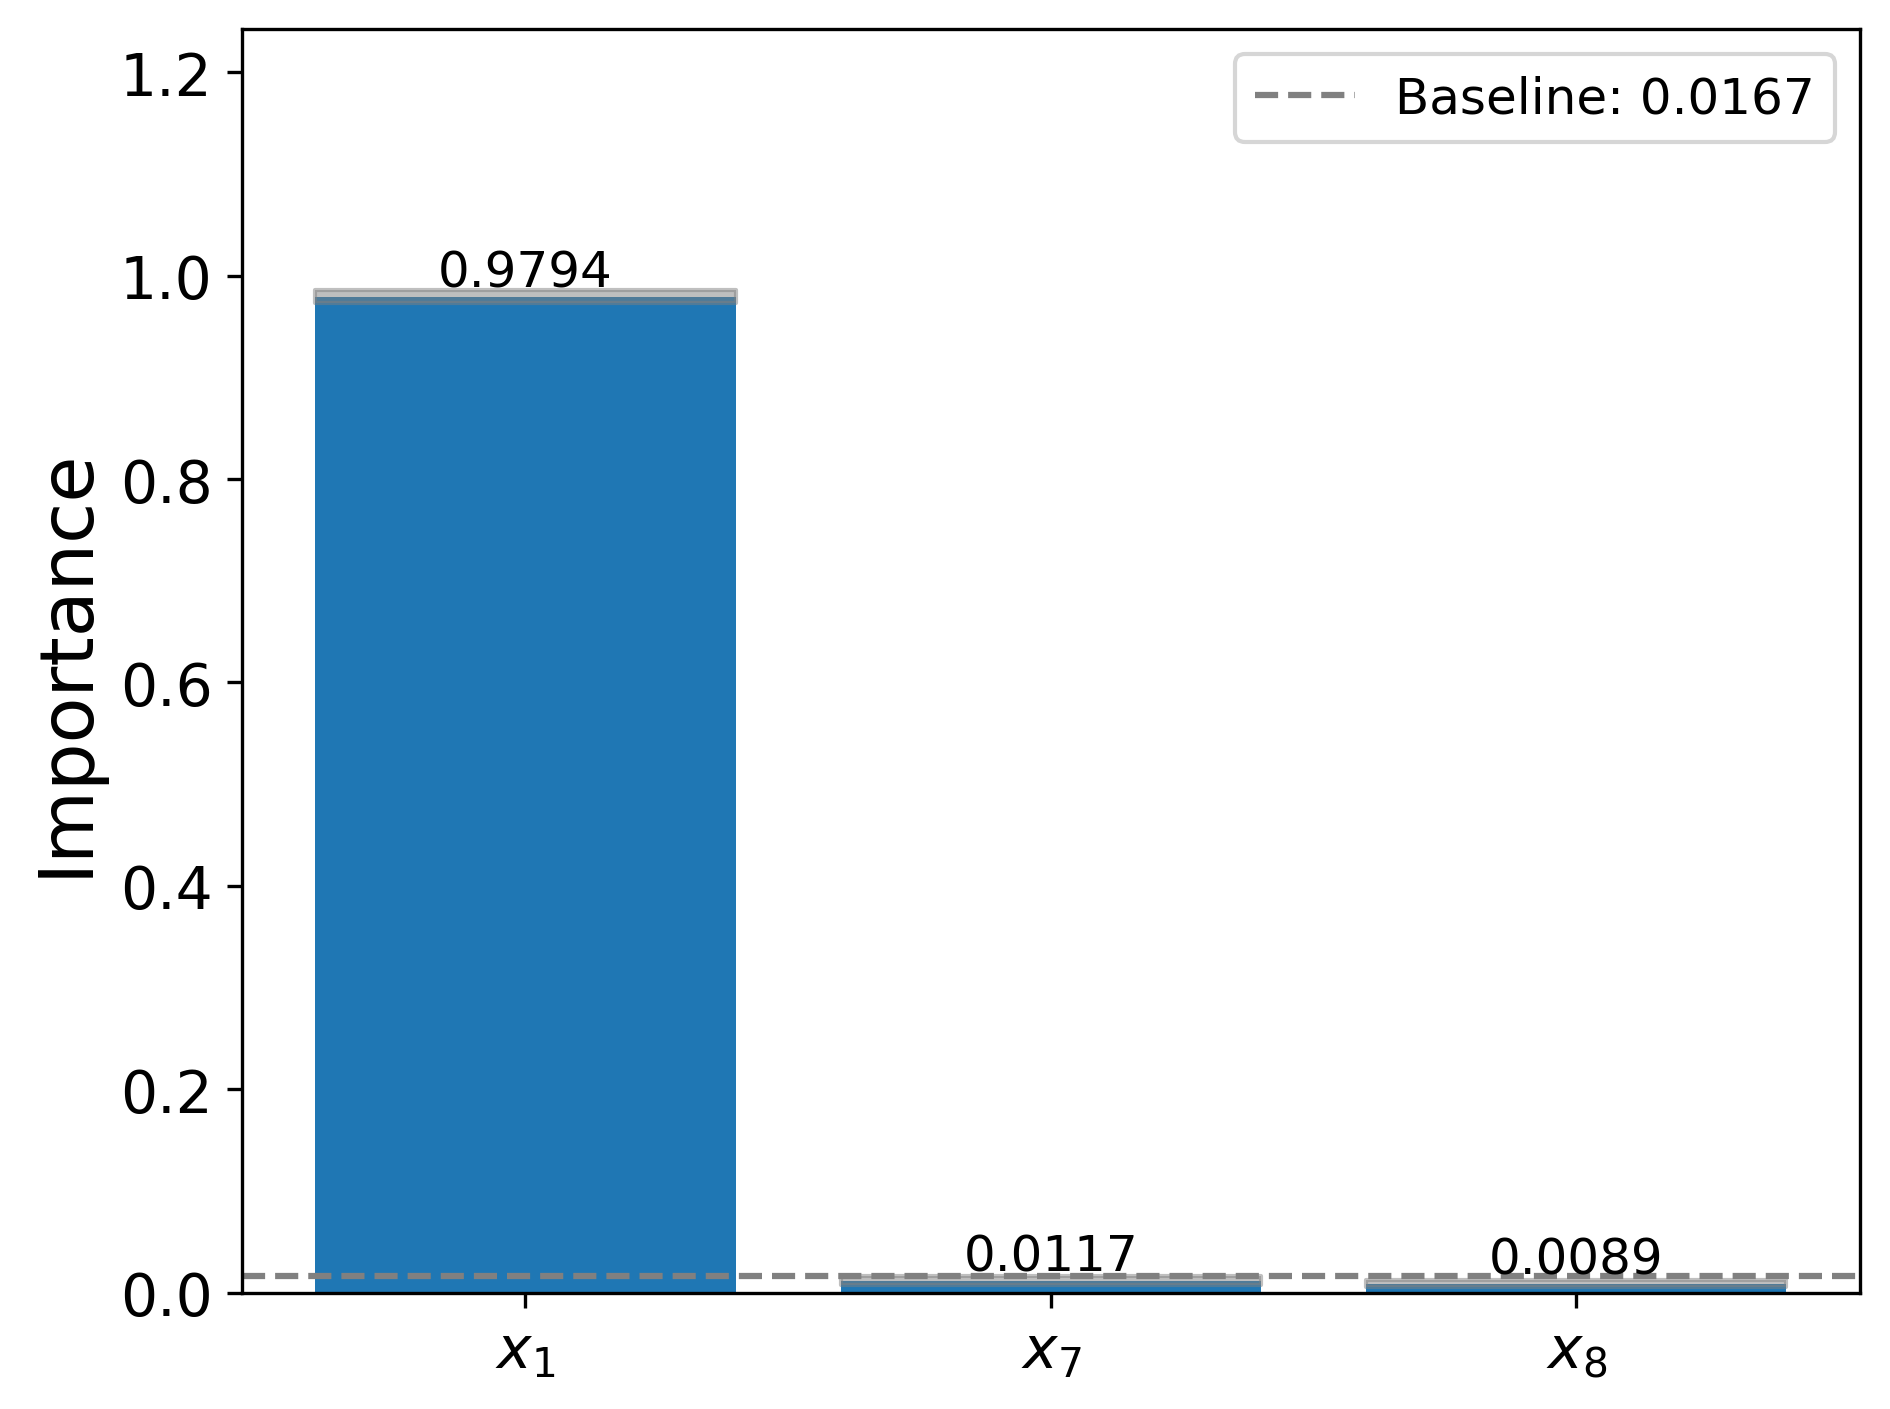

In [11]:
# Figure: learned importance
if dataset_name == "mock6":
    reordered_scores_mean = np.zeros_like(results["learned_importance_scores"]["mean"])
    reordered_scores_std = np.zeros_like(results["learned_importance_scores"]["std"])
    for i, idx in enumerate(order):
        reordered_scores_mean[idx] = results["learned_importance_scores"]["mean"][i]
        reordered_scores_std[idx] = results["learned_importance_scores"]["std"][i]

    feature_order_pairs = list(zip(features, order))
    sorted_pairs = sorted(feature_order_pairs, key=lambda x: x[1])
    reordered_features = [pair[0] for pair in sorted_pairs]

    scores_mean = reordered_scores_mean
    scores_std = reordered_scores_std
    baseline = results["learned_importance_baseline"]
    features = reordered_features
else:
    scores_mean = results["learned_importance_scores"]["mean"]
    scores_std = results["learned_importance_scores"]["std"]
    baseline = results["learned_importance_baseline"]
    features = features

plot_learned_importance(
    scores=scores_mean,
    errors=scores_std,
    baseline=baseline,
    features=features,
)

plot_learned_importance(
    scores=scores_mean,
    errors=scores_std,
    baseline=baseline,
    features=features,
    to_file=FIGURES_DIR / f"{prefix}learned_importance{suffix}.pdf",
)

plot_learned_importance(
    scores=scores_mean,
    errors=scores_std,
    baseline=baseline,
    features=features,
    to_file=FIGURES_DIR / f"{prefix}learned_importance{suffix}.png",
)

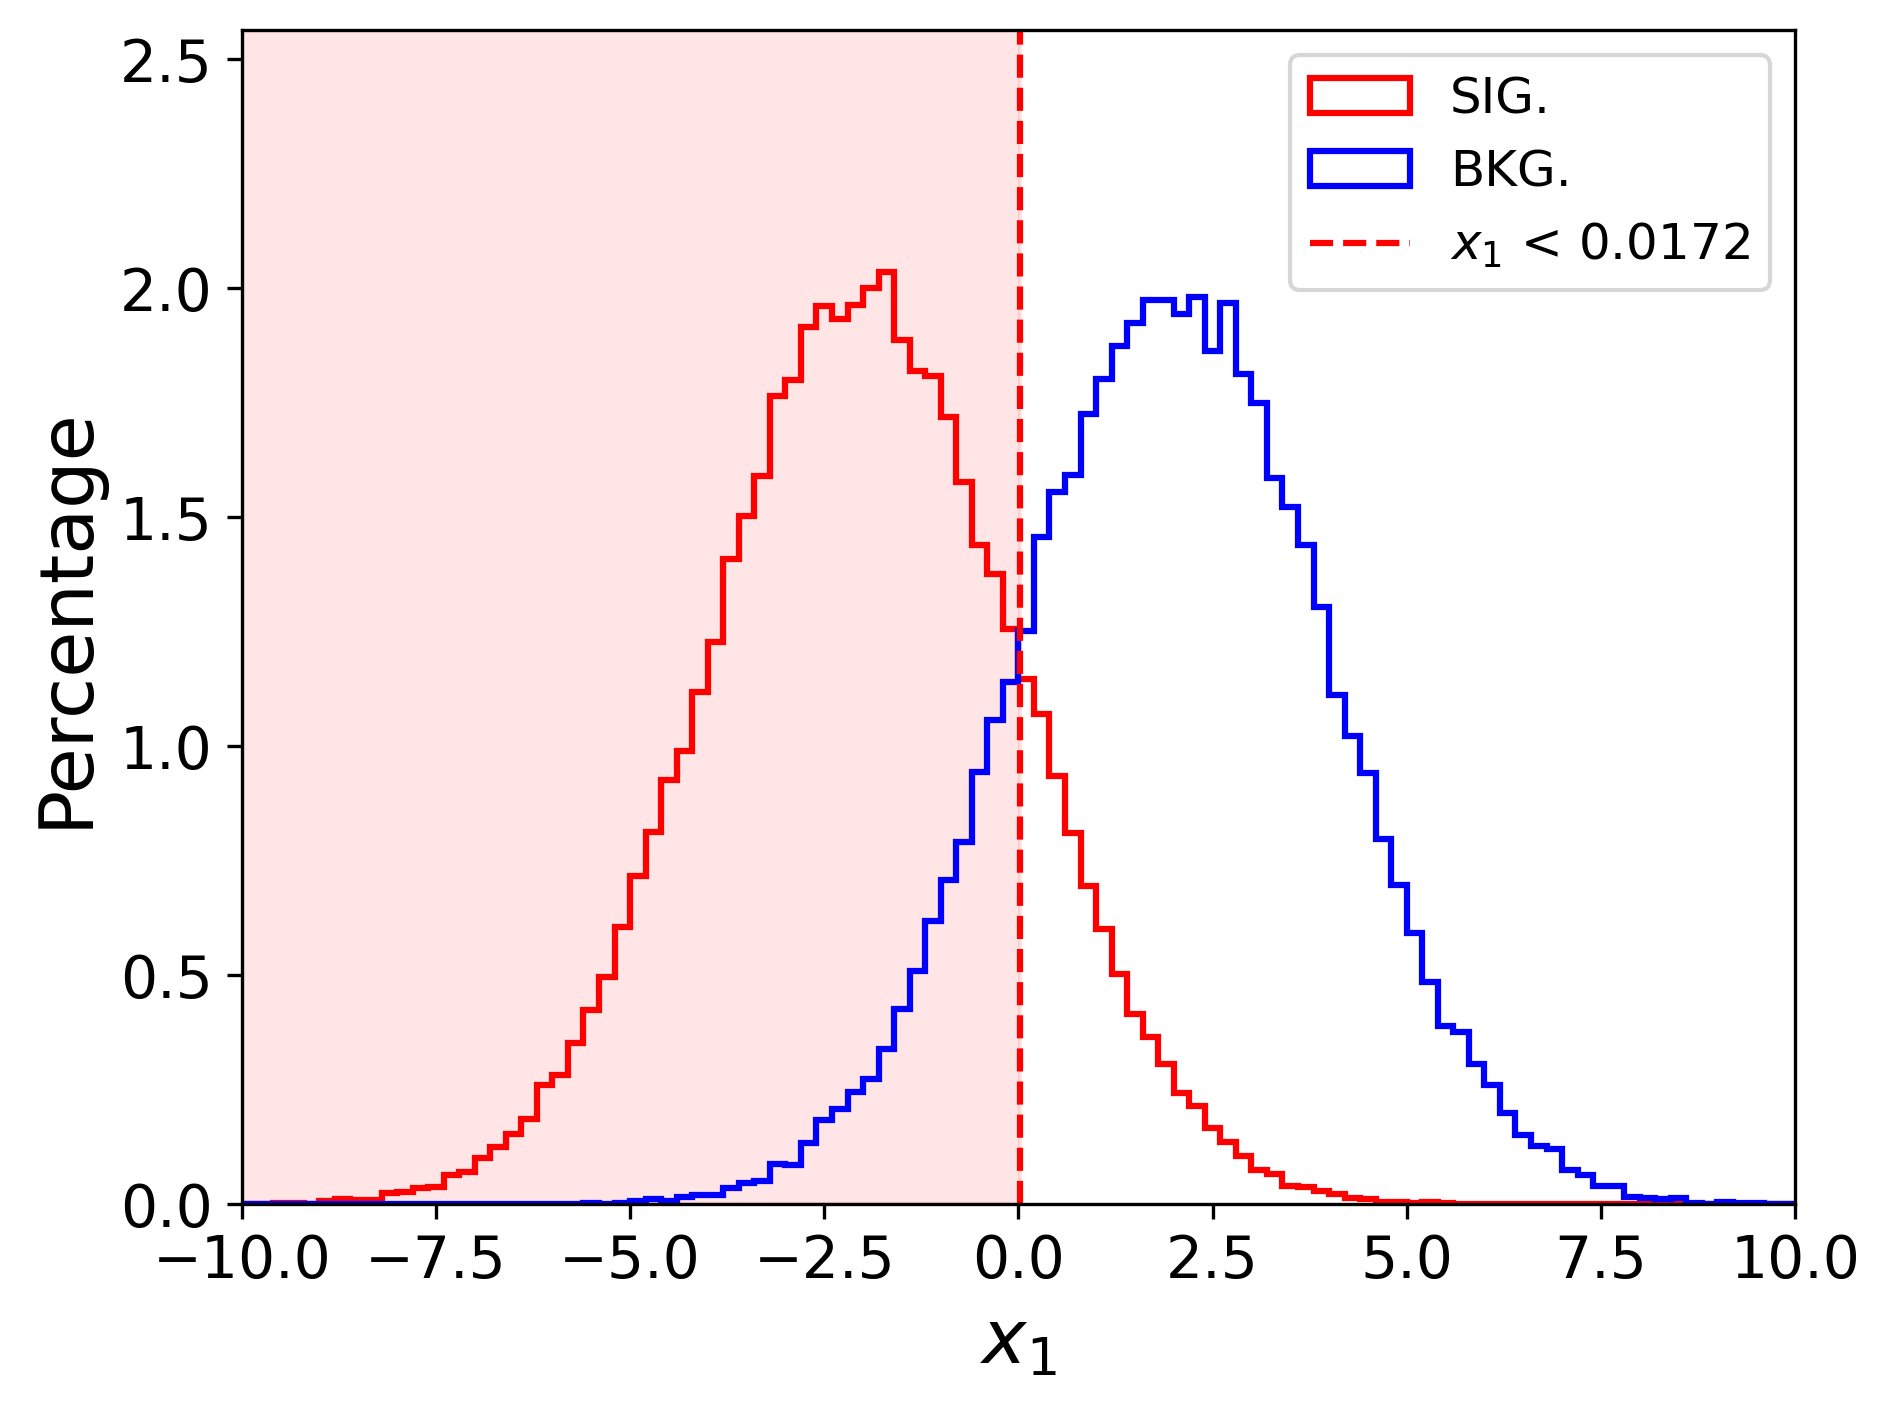

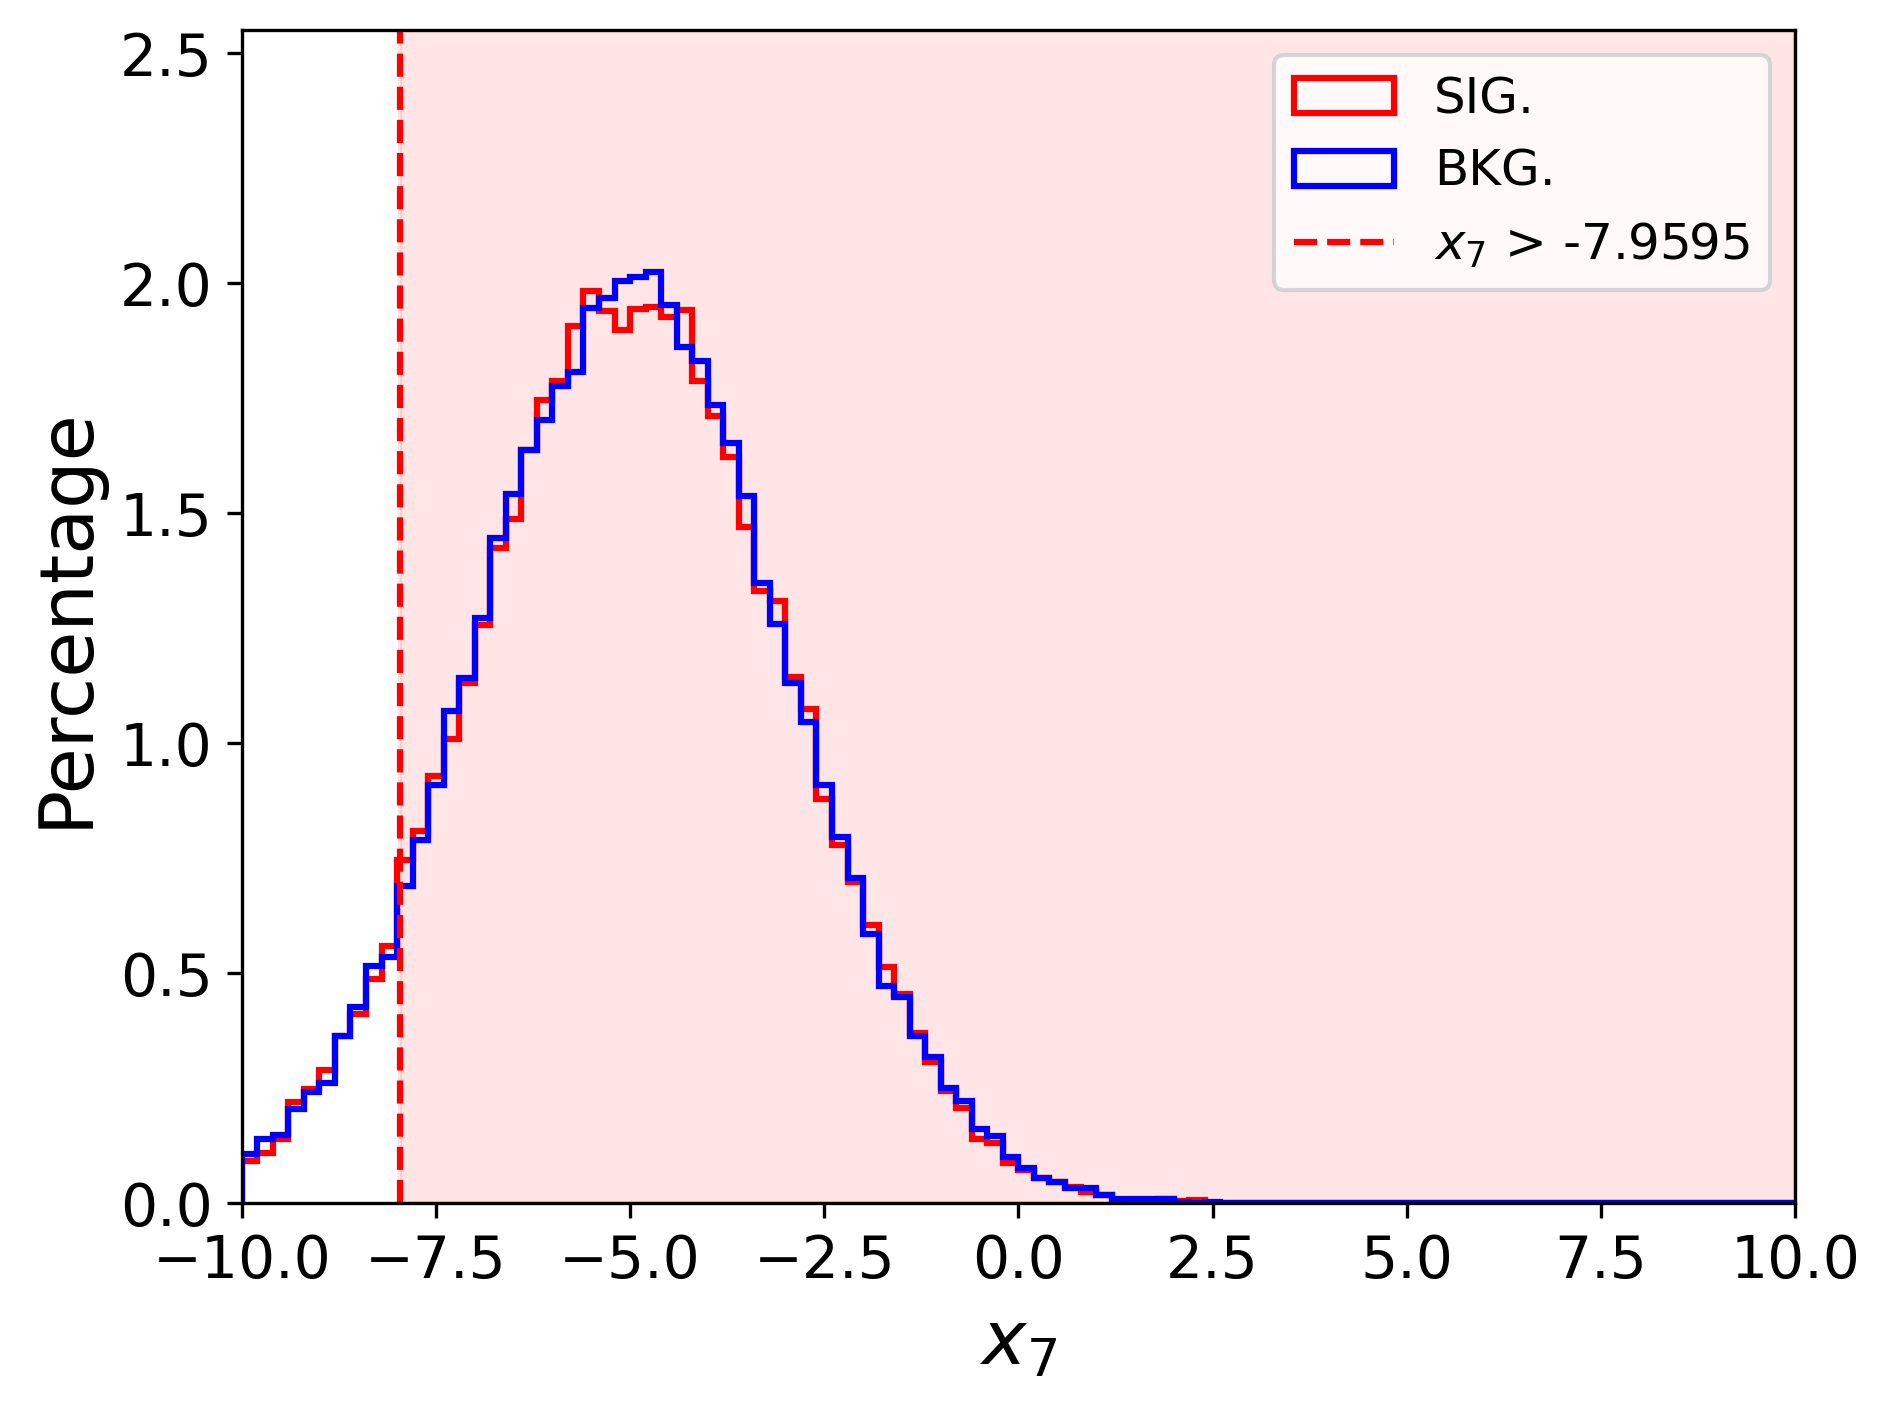

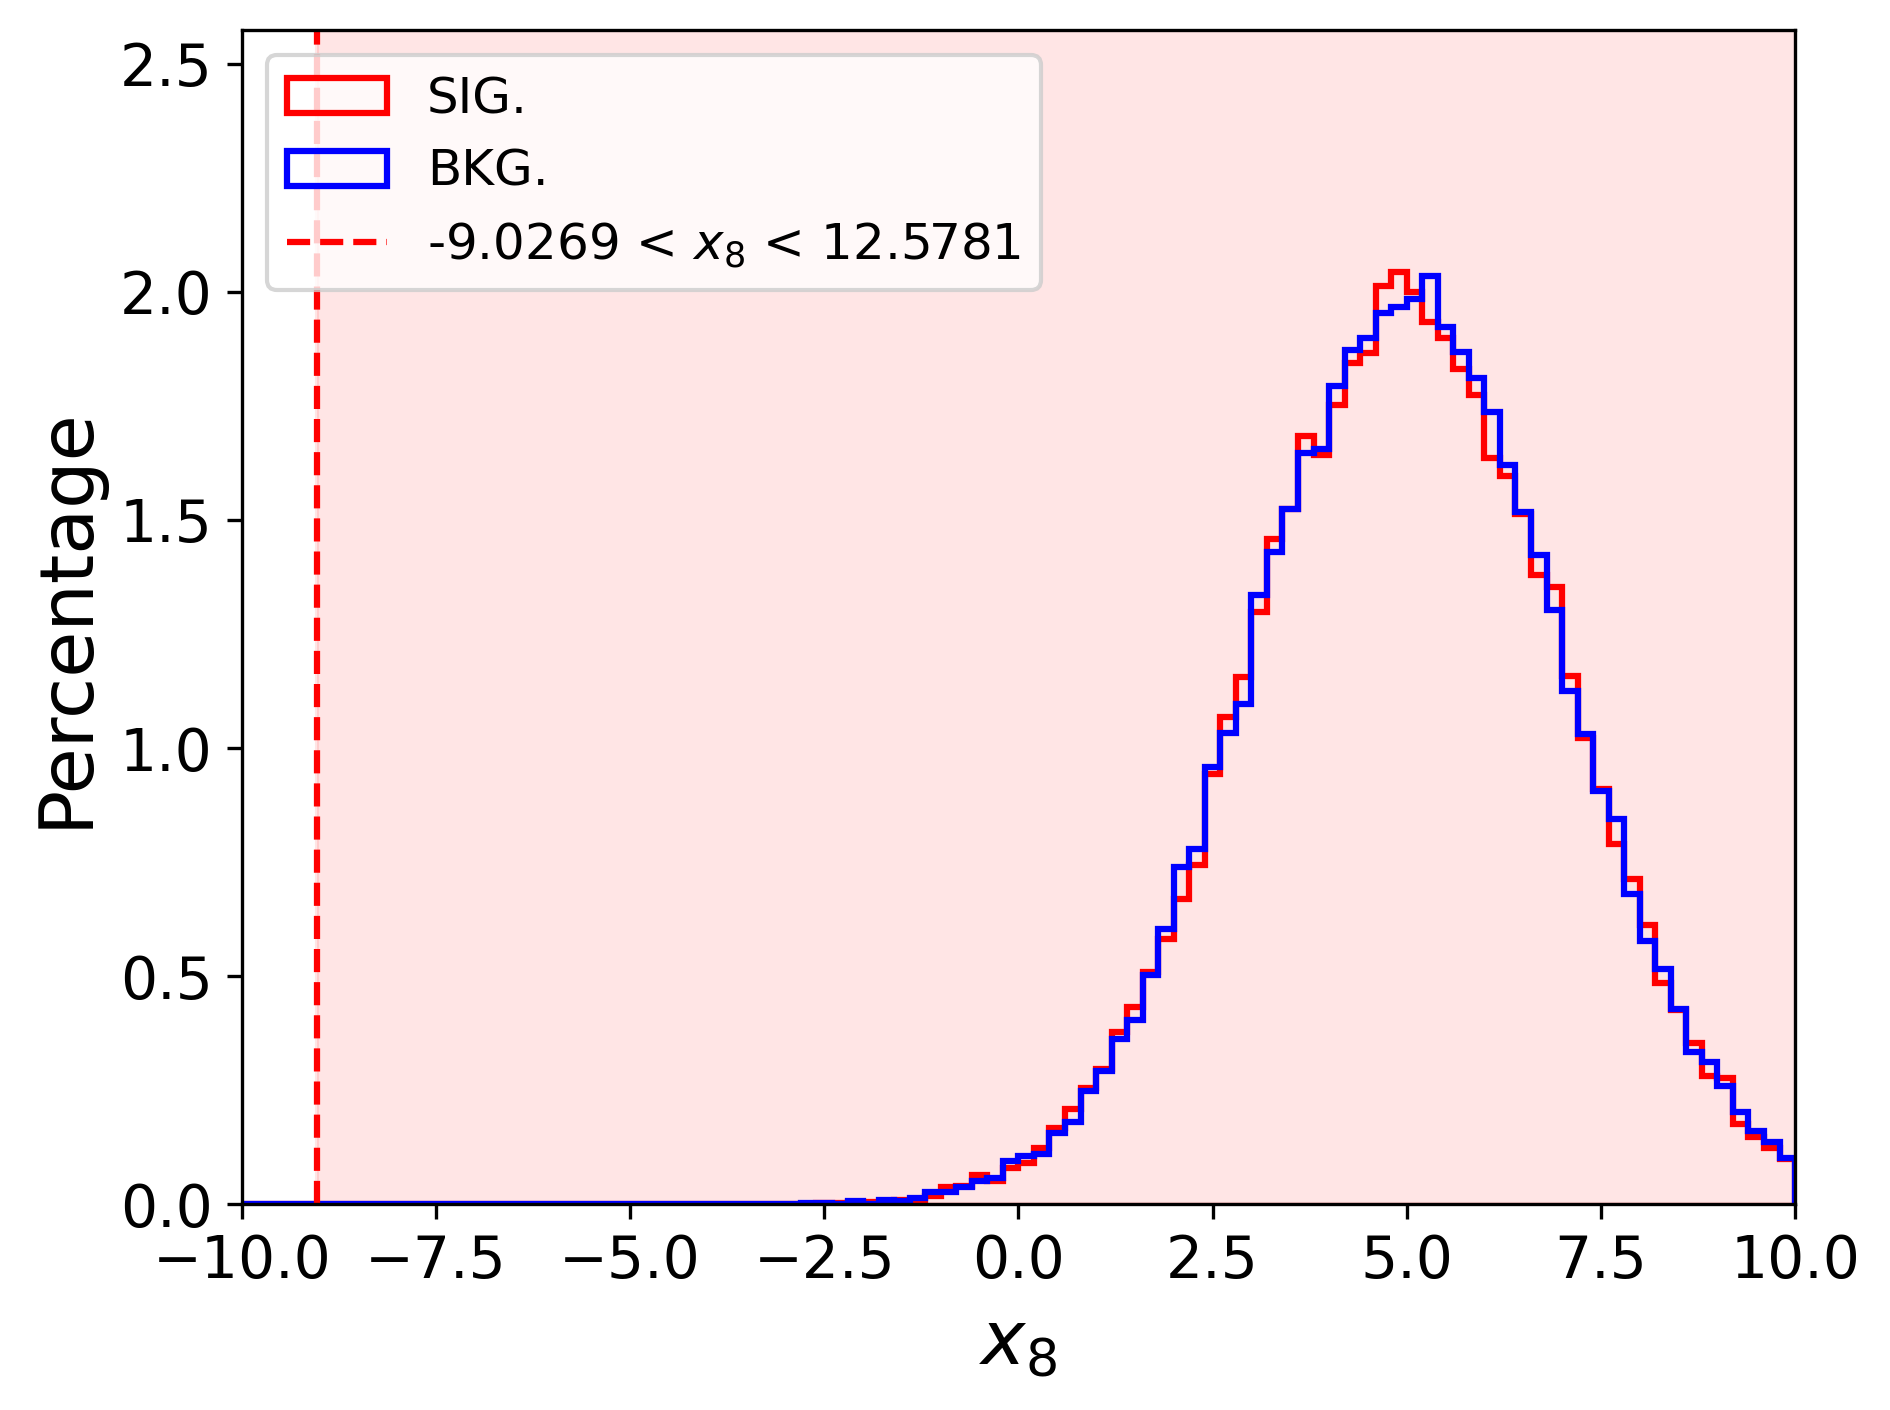

In [12]:
# Figure: learned cuts
features_str = [tex_to_str(feature) for feature in features]
is_selected = (
    np.array(results["learned_importance_scores"]["mean"])
    > results["learned_importance_baseline"]
)

df = pd.DataFrame(x_test, columns=features_str)
df["y"] = y_test.squeeze()

for i, feature in enumerate(features):
    sig = df.query("y == 1")[features_str[i]]
    bkg = df.query("y == 0")[features_str[i]]
    weights_sig = 100 * np.ones_like(sig) / len(df)
    weights_bkg = 100 * np.ones_like(bkg) / len(df)

    plot_learned_cut(
        case=results["learned_cuts"]["case"][i],
        index=results["learned_cuts"]["index"][i],
        boundaries=results["learned_cuts"]["boundaries_mean"][i],
        expression=results["learned_cuts"]["expression"][i]["lite"],
        data=[sig, bkg],
        bins=bins[i],
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
    )

    plot_learned_cut(
        case=results["learned_cuts"]["case"][i],
        index=results["learned_cuts"]["index"][i],
        boundaries=results["learned_cuts"]["boundaries_mean"][i],
        expression=results["learned_cuts"]["expression"][i]["lite"],
        data=[sig, bkg],
        bins=bins[i],
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
        to_file=FIGURES_DIR / f"{prefix}learned_cut:{features_str[i]}{suffix}.pdf",
    )

    plot_learned_cut(
        case=results["learned_cuts"]["case"][i],
        index=results["learned_cuts"]["index"][i],
        boundaries=results["learned_cuts"]["boundaries_mean"][i],
        expression=results["learned_cuts"]["expression"][i]["lite"],
        data=[sig, bkg],
        bins=bins[i],
        colors=["red", "blue"],
        labels=["SIG.", "BKG."],
        weights=[weights_sig, weights_bkg],
        xlabel=feature,
        ylabel="Percentage",
        to_file=FIGURES_DIR / f"{prefix}learned_cut:{features_str[i]}{suffix}.png",
    )

    if isinstance(checkpoints[0], LearnableCutFlowSequentialModel) and is_selected[i]:
        cut_query = results["learned_cuts"]["expression"][i]["lite"].replace(
            features[i], f"`{features_str[i]}`"
        )
        df = df.query(cut_query)

In [13]:
# Results
if rerun:
    with open(RESULTS_DIR / f"{prefix}results{suffix}.json", "w") as f:
        json.dump(results, f, indent=4)